# find better representation of methylation by calculating methylation via clusters not cells

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib_venn import venn2, venn3
import seaborn as sns
from ALLCools.mcds import MCDS 

In [2]:
# mcds_path = '/ceph/MethDev/pbio/kay/data/Arab10_All_mcds.mcds'
mcds_path = '/ceph/MethDev/pbio/All_mcds.mcds'
rna_path = '/ceph/MethDev/pbio/novaseq_demux/count.csv'
meta_path ='/ceph/MethDev/pbio/data/Arab6_cells_and_clusters.csv'

In [3]:
mcds = MCDS.open(mcds_paths = mcds_path, var_dim = 'gene')
rna_matrix = pd.read_csv(rna_path).T
meta = pd.read_csv(meta_path)

In [4]:
#re-format and combine clusters
meta['Cell'] = meta['Cell'].str.replace('.','-')
meta = meta.set_index('Cell')
# meta['Cluster'] = meta['Cluster'].replace({6:1,0:1,4:1,5:3})

In [5]:
rna_matrix['cluster'] = meta['Cluster']
rna_matrix = rna_matrix.groupby('cluster').mean()
rna_matrix

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01046,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,...,ATMG01380,ATMG01390,ATMG01400,ATMG01410,ATMG09450,ATMG09730,ATMG09740,ATMG09950,ATMG09960,ATMG09980
cluster,,,,,,,,,,,,,,,,,,,,,
0.0,2.377856,30.949033,9.337434,51.249561,0.0,24.173989,236.629174,0.014060,15.038664,9.994728,...,0.022847,0.906854,0.003515,0.026362,0.0,0.0,0.005272,0.000000,0.007030,0.000000
1.0,3.427461,56.386010,16.386010,78.549223,0.0,48.961140,297.917098,0.233161,35.730570,12.906736,...,0.103627,1.093264,0.020725,0.025907,0.0,0.0,0.002591,0.000000,0.023316,0.015544
2.0,0.037791,15.168605,8.904070,27.770349,0.0,7.360465,63.476744,0.005814,7.709302,2.101744,...,0.046512,0.584302,0.000000,0.000000,0.0,0.0,0.203488,0.014535,0.008721,0.005814
3.0,0.929936,34.477707,5.878981,39.506369,0.0,6.152866,83.181529,0.038217,15.863057,9.687898,...,0.025478,1.082803,0.022293,0.006369,0.0,0.0,0.015924,0.000000,0.000000,0.003185
4.0,2.313070,41.820669,8.835866,32.340426,0.0,11.702128,93.541033,0.048632,14.635258,4.176292,...,0.015198,0.787234,0.006079,0.003040,0.0,0.0,0.006079,0.000000,0.003040,0.003040
5.0,0.647959,17.770408,0.464286,34.061224,0.0,4.556122,71.239796,0.974490,5.683673,10.770408,...,0.010204,0.591837,0.045918,0.000000,0.0,0.0,0.071429,0.000000,0.005102,0.015306
6.0,1.361582,67.073446,3.627119,26.548023,0.0,26.491525,86.350282,0.045198,37.610169,16.655367,...,0.101695,1.406780,0.022599,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.062147
7.0,11.107595,33.322785,4.727848,32.734177,0.0,16.993671,68.582278,5.284810,5.677215,8.139241,...,0.018987,1.424051,0.012658,0.012658,0.0,0.0,0.037975,0.000000,0.006329,0.006329
8.0,0.917293,44.932331,10.789474,42.120301,0.0,5.676692,78.849624,0.045113,11.548872,8.924812,...,0.037594,0.518797,0.037594,0.037594,0.0,0.0,0.060150,0.090226,0.015038,0.015038


In [6]:
rna_matrix

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01046,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,...,ATMG01380,ATMG01390,ATMG01400,ATMG01410,ATMG09450,ATMG09730,ATMG09740,ATMG09950,ATMG09960,ATMG09980
cluster,,,,,,,,,,,,,,,,,,,,,
0.0,2.377856,30.949033,9.337434,51.249561,0.0,24.173989,236.629174,0.014060,15.038664,9.994728,...,0.022847,0.906854,0.003515,0.026362,0.0,0.0,0.005272,0.000000,0.007030,0.000000
1.0,3.427461,56.386010,16.386010,78.549223,0.0,48.961140,297.917098,0.233161,35.730570,12.906736,...,0.103627,1.093264,0.020725,0.025907,0.0,0.0,0.002591,0.000000,0.023316,0.015544
2.0,0.037791,15.168605,8.904070,27.770349,0.0,7.360465,63.476744,0.005814,7.709302,2.101744,...,0.046512,0.584302,0.000000,0.000000,0.0,0.0,0.203488,0.014535,0.008721,0.005814
3.0,0.929936,34.477707,5.878981,39.506369,0.0,6.152866,83.181529,0.038217,15.863057,9.687898,...,0.025478,1.082803,0.022293,0.006369,0.0,0.0,0.015924,0.000000,0.000000,0.003185
4.0,2.313070,41.820669,8.835866,32.340426,0.0,11.702128,93.541033,0.048632,14.635258,4.176292,...,0.015198,0.787234,0.006079,0.003040,0.0,0.0,0.006079,0.000000,0.003040,0.003040
5.0,0.647959,17.770408,0.464286,34.061224,0.0,4.556122,71.239796,0.974490,5.683673,10.770408,...,0.010204,0.591837,0.045918,0.000000,0.0,0.0,0.071429,0.000000,0.005102,0.015306
6.0,1.361582,67.073446,3.627119,26.548023,0.0,26.491525,86.350282,0.045198,37.610169,16.655367,...,0.101695,1.406780,0.022599,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.062147
7.0,11.107595,33.322785,4.727848,32.734177,0.0,16.993671,68.582278,5.284810,5.677215,8.139241,...,0.018987,1.424051,0.012658,0.012658,0.0,0.0,0.037975,0.000000,0.006329,0.006329
8.0,0.917293,44.932331,10.789474,42.120301,0.0,5.676692,78.849624,0.045113,11.548872,8.924812,...,0.037594,0.518797,0.037594,0.037594,0.0,0.0,0.060150,0.090226,0.015038,0.015038


In [7]:
#get methylation fraction 
mCGN_mc = mcds.sel(
    mc_type = 'CGN',
    count_type = 'mc').gene_da.to_pandas()
mCGN_cov = mcds.sel(
    mc_type = 'CGN',
    count_type = 'cov').gene_da.to_pandas()
mCGN_frac = mCGN_mc.div(mCGN_cov).fillna(0)

In [8]:
mCGN_mc['cluster'] = meta['Cluster']
mCGN_mc_by_cluster = mCGN_mc.groupby('cluster').sum()
mCGN_mc_by_cluster
mCGN_cov['cluster'] = meta['Cluster']
mCGN_cov_by_cluster = mCGN_cov.groupby('cluster').sum()

In [11]:
mCGN_mc

gene,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ATCG01230,ATCG01240,ATCG01250,ATCG01260,ATCG01270,ATCG01280,ATCG01290,ATCG01300,ATCG01310,cluster
cell,,,,,,,,,,,,,,,,,,,,,
NJ_221007_P1-2-K15-I15,4,0,0,0,111,0,0,5,0,14,...,0,0,0,0,0,0,0,0,0,1.0
NJ_221007_P1-2-K15-A3,2,5,0,0,111,0,2,3,0,6,...,0,0,0,0,0,0,0,0,0,1.0
NJ_221007_P1-2-K15-I16,1,0,0,0,98,1,2,7,0,23,...,0,0,0,0,0,0,0,0,0,1.0
NJ_221007_P1-2-K15-I3,0,0,0,0,60,0,0,6,0,0,...,0,0,0,0,0,0,0,0,0,12.0
NJ_221007_P1-2-K15-D3,3,0,0,0,64,0,0,2,0,7,...,0,0,0,0,0,0,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NJ_221007_P8-5-G10-B9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2.0
NJ_221007_P8-5-G10-O10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3.0
NJ_221007_P8-5-G10-I10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2.0


In [10]:
mCGN_frac_by_cluster = mCGN_mc_by_cluster.div(mCGN_cov_by_cluster).fillna(0)
mCGN_frac_by_cluster

gene,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ATCG01220,ATCG01230,ATCG01240,ATCG01250,ATCG01260,ATCG01270,ATCG01280,ATCG01290,ATCG01300,ATCG01310
cluster,,,,,,,,,,,,,,,,,,,,,
0.0,0.025490,0.069221,0.000000,0.004898,0.597558,0.068908,0.507042,0.133719,0.008969,0.119029,...,0.0,0.038462,0.076923,0.0,0.0,0.0,0.027778,0.0,0.0,0.000000
1.0,0.028993,0.057388,0.009804,0.006477,0.603006,0.060901,0.518519,0.131061,0.004748,0.114884,...,0.0,0.000000,0.068966,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
2.0,0.032244,0.058621,0.027027,0.004906,0.621651,0.092033,0.493976,0.131535,0.007092,0.120173,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
3.0,0.034498,0.048050,0.000000,0.005613,0.614978,0.083645,0.582278,0.131068,0.002392,0.128700,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
4.0,0.025919,0.064257,0.000000,0.004799,0.604484,0.062181,0.533333,0.130783,0.006623,0.135154,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.011494,0.0,0.0,0.111111
5.0,0.021434,0.056250,0.000000,0.002647,0.607248,0.067816,0.535354,0.122752,0.003425,0.135616,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
6.0,0.035757,0.059511,0.000000,0.002796,0.613012,0.065217,0.514286,0.135235,0.000000,0.125036,...,0.0,0.000000,0.000000,0.0,0.5,0.0,0.000000,0.0,0.0,0.000000
7.0,0.026185,0.061662,0.000000,0.005244,0.648350,0.103922,0.523810,0.120798,0.005102,0.124211,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
8.0,0.042767,0.063752,0.000000,0.004905,0.633127,0.048346,0.339623,0.152623,0.015504,0.118291,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.100000


In [40]:
#filter out ATM ATC and by mean methylation level
filtered_df = mCGN_frac_by_cluster.loc[
:,~mCGN_frac_by_cluster.columns.str.startswith(('ATM', 'ATC'))
& 
(mCGN_frac_by_cluster.mean(axis=0)>0.03)
]

In [41]:
filtered_df

gene,AT1G01020,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G01060,AT1G01150,AT1G01220,AT1G01230,AT1G01240,...,AT5G67385,AT5G67440,AT5G67470,AT5G67500,AT5G67530,AT5G67540,AT5G67570,AT5G67580,AT5G67610,AT5G67630
cluster,,,,,,,,,,,,,,,,,,,,,
0.0,0.069221,0.597558,0.068908,0.507042,0.133719,0.119029,0.125474,0.294083,0.066113,0.053755,...,0.207325,0.040118,0.035840,0.117082,0.297148,0.291778,0.226614,0.097147,0.146733,0.079179
1.0,0.057388,0.603006,0.060901,0.518519,0.131061,0.114884,0.105580,0.284311,0.059720,0.042728,...,0.199668,0.036056,0.035247,0.120266,0.275310,0.299264,0.220784,0.101418,0.153587,0.071560
2.0,0.058621,0.621651,0.092033,0.493976,0.131535,0.120173,0.137964,0.304712,0.088514,0.037474,...,0.216643,0.044677,0.034151,0.126146,0.329412,0.320830,0.219957,0.086188,0.149219,0.080207
3.0,0.048050,0.614978,0.083645,0.582278,0.131068,0.128700,0.122354,0.296836,0.066581,0.065938,...,0.094606,0.047649,0.041115,0.122634,0.323377,0.264831,0.223773,0.110066,0.126192,0.077694
4.0,0.064257,0.604484,0.062181,0.533333,0.130783,0.135154,0.133706,0.317882,0.090328,0.047130,...,0.228042,0.053190,0.037139,0.121908,0.303265,0.302717,0.217951,0.104617,0.121053,0.069497
5.0,0.056250,0.607248,0.067816,0.535354,0.122752,0.135616,0.142302,0.311032,0.068723,0.046402,...,0.116910,0.035667,0.032719,0.132767,0.315268,0.278857,0.245702,0.105356,0.139180,0.082990
6.0,0.059511,0.613012,0.065217,0.514286,0.135235,0.125036,0.140368,0.300723,0.072381,0.044242,...,0.188767,0.038814,0.029083,0.126939,0.328006,0.263374,0.214307,0.080844,0.135812,0.075269
7.0,0.061662,0.648350,0.103922,0.523810,0.120798,0.124211,0.104567,0.251309,0.076302,0.043810,...,0.304369,0.044271,0.050479,0.108457,0.345022,0.304727,0.231698,0.134703,0.128773,0.073805
8.0,0.063752,0.633127,0.048346,0.339623,0.152623,0.118291,0.111975,0.313628,0.075560,0.057841,...,0.175227,0.034000,0.036342,0.119257,0.319940,0.283767,0.224671,0.089888,0.135767,0.085005


In [50]:
#filter out ATM ATC and by mean methylation level
filtered_df_2 = mCGN_frac_by_cluster.loc[
:,~mCGN_frac_by_cluster.columns.str.startswith(('ATM', 'ATC'))
& 
(mCGN_frac_by_cluster.mean(axis=0)>0.02)
# &
# (mCGN_frac_by_cluster.mean(axis=0)<0.02)
]
filtered_df_2

gene,AT1G01010,AT1G01020,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G01060,AT1G01090,AT1G01150,AT1G01220,...,AT5G67385,AT5G67440,AT5G67470,AT5G67500,AT5G67530,AT5G67540,AT5G67570,AT5G67580,AT5G67610,AT5G67630
cluster,,,,,,,,,,,,,,,,,,,,,
0.0,0.025490,0.069221,0.597558,0.068908,0.507042,0.133719,0.119029,0.023911,0.125474,0.294083,...,0.207325,0.040118,0.035840,0.117082,0.297148,0.291778,0.226614,0.097147,0.146733,0.079179
1.0,0.028993,0.057388,0.603006,0.060901,0.518519,0.131061,0.114884,0.019623,0.105580,0.284311,...,0.199668,0.036056,0.035247,0.120266,0.275310,0.299264,0.220784,0.101418,0.153587,0.071560
2.0,0.032244,0.058621,0.621651,0.092033,0.493976,0.131535,0.120173,0.030888,0.137964,0.304712,...,0.216643,0.044677,0.034151,0.126146,0.329412,0.320830,0.219957,0.086188,0.149219,0.080207
3.0,0.034498,0.048050,0.614978,0.083645,0.582278,0.131068,0.128700,0.024495,0.122354,0.296836,...,0.094606,0.047649,0.041115,0.122634,0.323377,0.264831,0.223773,0.110066,0.126192,0.077694
4.0,0.025919,0.064257,0.604484,0.062181,0.533333,0.130783,0.135154,0.025387,0.133706,0.317882,...,0.228042,0.053190,0.037139,0.121908,0.303265,0.302717,0.217951,0.104617,0.121053,0.069497
5.0,0.021434,0.056250,0.607248,0.067816,0.535354,0.122752,0.135616,0.021124,0.142302,0.311032,...,0.116910,0.035667,0.032719,0.132767,0.315268,0.278857,0.245702,0.105356,0.139180,0.082990
6.0,0.035757,0.059511,0.613012,0.065217,0.514286,0.135235,0.125036,0.021465,0.140368,0.300723,...,0.188767,0.038814,0.029083,0.126939,0.328006,0.263374,0.214307,0.080844,0.135812,0.075269
7.0,0.026185,0.061662,0.648350,0.103922,0.523810,0.120798,0.124211,0.021713,0.104567,0.251309,...,0.304369,0.044271,0.050479,0.108457,0.345022,0.304727,0.231698,0.134703,0.128773,0.073805
8.0,0.042767,0.063752,0.633127,0.048346,0.339623,0.152623,0.118291,0.020018,0.111975,0.313628,...,0.175227,0.034000,0.036342,0.119257,0.319940,0.283767,0.224671,0.089888,0.135767,0.085005


In [45]:
filtered_df_2.columns not in filtered_df.columns

TypeError: unhashable type: 'Index'

In [27]:
# #should get around 6000 genes
# filtered_df = mCGN_frac_by_cluster.loc[:, ~(mCGN_frac_by_cluster < 0.03).all(axis=0)]
# filtered_df

In [53]:
filtered_df_2['AT4G30400']

cluster
0.0     0.187187
1.0     0.188917
2.0     0.208333
3.0     0.038911
4.0     0.196899
5.0     0.022835
6.0     0.179267
7.0     0.123724
8.0     0.201337
9.0     0.230469
10.0    0.138144
11.0    0.154455
12.0    0.155216
13.0    0.217949
14.0    0.221519
Name: AT4G30400, dtype: float64

In [19]:
# filtered_meth_df = mCGN_frac_by_cluster[mCGN_frac_by_cluster.apply(lambda x: (x >= 0.1).any(), axis=0)]
# filtered_meth_df

In [52]:
filtered_df_2.to_csv('/ceph/MethDev/pbio/kay/data/mCGN_filtered_002.csv')

In [87]:
# #assign cluster to meth data
# mCGN_frac['cluster'] = meta['Cluster']
# #exclude cluster 2/9
# # mCGN_frac = mCGN_frac[~mCGN_frac['cluster'].isin([2])]
# # mCGN_frac = mCGN_frac[~mCGN_frac['cluster'].isin([9])]
# mCGN_frac

In [88]:
# cluster_meth_matrix = mCGN_frac.groupby('cluster').mean().T
# filtered_meth_df = cluster_meth_matrix[cluster_meth_matrix.apply(lambda x: (x >= 0.0).any(), axis=1)]
# filtered_meth_df

In [89]:
# get gene index for methylation values exceeding certain threshold
filtered_index = mCGN_frac_by_cluster.index

In [29]:
#filter cluster information
rna_matrix['cluster'] = meta['Cluster']
#.replace({6:1,0:1,4:1,5:3})
# rna_matrix = rna_matrix[~rna_matrix['cluster'].isin([2])]
rna_matrix
#= rna_matrix.groupby('cluster').mean().T
#cluster_rna_matrix

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01046,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,...,ATMG01390,ATMG01400,ATMG01410,ATMG09450,ATMG09730,ATMG09740,ATMG09950,ATMG09960,ATMG09980,cluster
NJ_221007_P1-2-K15-J3,0,0,0,44,0,69,0,0,0,0,...,20,0,0,0,0,0,0,0,0,1.0
NJ_221007_P1-2-K15-E16,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,12.0
NJ_221007_P1-2-K15-C15,0,0,0,3,0,110,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4.0
NJ_221007_P1-2-K15-J4,0,78,0,623,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.0
NJ_221007_P1-2-K15-M16,0,3,0,36,0,28,0,0,0,1,...,0,0,0,0,0,0,0,0,0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NJ_221007_P8-5-G10-N10,0,6,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4.0
NJ_221007_P8-5-G10-F22,0,2,0,1,0,0,15,0,0,0,...,0,0,0,0,0,0,0,0,0,4.0
NJ_221007_P8-5-G10-O10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3.0
NJ_221007_P8-5-G10-N21,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2.0


In [90]:
rna_matrix

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01046,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,...,ATMG01380,ATMG01390,ATMG01400,ATMG01410,ATMG09450,ATMG09730,ATMG09740,ATMG09950,ATMG09960,ATMG09980
cluster,,,,,,,,,,,,,,,,,,,,,
0.0,2.377856,30.949033,9.337434,51.249561,0.0,24.173989,236.629174,0.014060,15.038664,9.994728,...,0.022847,0.906854,0.003515,0.026362,0.0,0.0,0.005272,0.000000,0.007030,0.000000
1.0,3.427461,56.386010,16.386010,78.549223,0.0,48.961140,297.917098,0.233161,35.730570,12.906736,...,0.103627,1.093264,0.020725,0.025907,0.0,0.0,0.002591,0.000000,0.023316,0.015544
2.0,0.037791,15.168605,8.904070,27.770349,0.0,7.360465,63.476744,0.005814,7.709302,2.101744,...,0.046512,0.584302,0.000000,0.000000,0.0,0.0,0.203488,0.014535,0.008721,0.005814
3.0,0.929936,34.477707,5.878981,39.506369,0.0,6.152866,83.181529,0.038217,15.863057,9.687898,...,0.025478,1.082803,0.022293,0.006369,0.0,0.0,0.015924,0.000000,0.000000,0.003185
4.0,2.313070,41.820669,8.835866,32.340426,0.0,11.702128,93.541033,0.048632,14.635258,4.176292,...,0.015198,0.787234,0.006079,0.003040,0.0,0.0,0.006079,0.000000,0.003040,0.003040
5.0,0.647959,17.770408,0.464286,34.061224,0.0,4.556122,71.239796,0.974490,5.683673,10.770408,...,0.010204,0.591837,0.045918,0.000000,0.0,0.0,0.071429,0.000000,0.005102,0.015306
6.0,1.361582,67.073446,3.627119,26.548023,0.0,26.491525,86.350282,0.045198,37.610169,16.655367,...,0.101695,1.406780,0.022599,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.062147
7.0,11.107595,33.322785,4.727848,32.734177,0.0,16.993671,68.582278,5.284810,5.677215,8.139241,...,0.018987,1.424051,0.012658,0.012658,0.0,0.0,0.037975,0.000000,0.006329,0.006329
8.0,0.917293,44.932331,10.789474,42.120301,0.0,5.676692,78.849624,0.045113,11.548872,8.924812,...,0.037594,0.518797,0.037594,0.037594,0.0,0.0,0.060150,0.090226,0.015038,0.015038


In [27]:
# filtered_rna_df = cluster_rna_matrix.reindex(filtered_index)
# filtered_rna_df

In [91]:
corr_values = mCGN_frac_by_cluster.corrwith(rna_matrix, axis =0)
corr_values

AT1G01010   -0.387252
AT1G01020    0.120394
AT1G03987   -0.069537
AT1G01030    0.578516
AT1G01040   -0.458769
               ...   
ATCG01270         NaN
ATCG01280    0.069994
ATCG01290         NaN
ATCG01300         NaN
ATCG01310   -0.142430
Length: 32833, dtype: float64

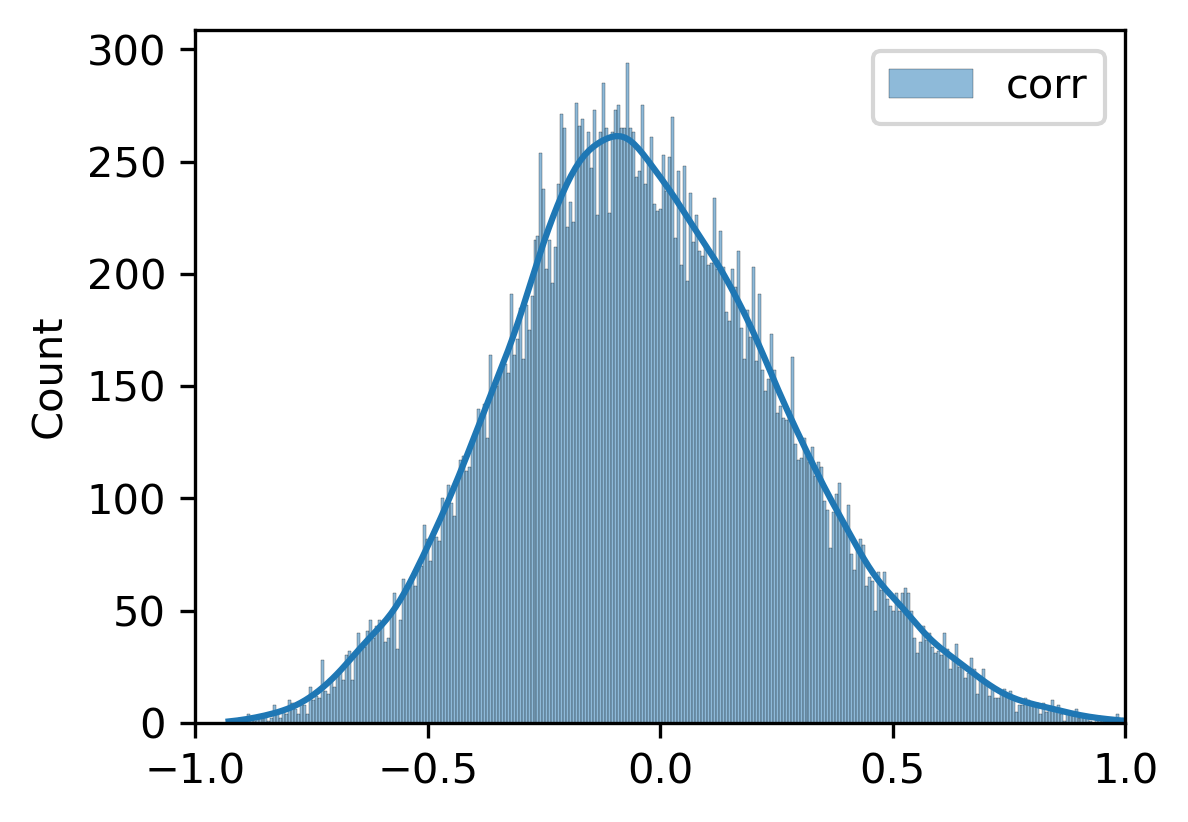

In [92]:
fig, ax = plt.subplots(figsize = (4,3), dpi = 300)
sns.histplot(corr_values, ax = ax,kde=True,bins=300, label = 'corr')
# sns.distplot(corr_df_diagonal_values_2, ax = ax,kde=True,bins=300, label = 'corr')
# sns.distplot(s_corr_df_diagonal_values,ax = ax, kde=True,bins=300, label = 'shuffle')

ax.set_xlim(-1,1)
# ax.axvline(x=0, color='red', linestyle='--', label='baseline')
# ax.set_xlabel(f'{mc_type} {condition} chr{chromosome}')
plt.legend()
# fig.savefig(f'/ceph/MethDev/pbio/kay/results/0413_filtered_exclude2_9_mc_rna_correlation.pdf', bbox_inches='tight')

In [93]:
thres = -0.8
(corr_values<=thres).sum()

50

In [94]:
rna_matrix = rna_matrix.T
rna_matrix

cluster,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0
AT1G01010,2.377856,3.427461,0.037791,0.929936,2.313070,0.647959,1.361582,11.107595,0.917293,6.978723,10.272727,5.679487,0.980392,20.04,0.1250
AT1G01020,30.949033,56.386010,15.168605,34.477707,41.820669,17.770408,67.073446,33.322785,44.932331,6.425532,29.935065,36.628205,15.941176,96.24,19.8750
AT1G01030,9.337434,16.386010,8.904070,5.878981,8.835866,0.464286,3.627119,4.727848,10.789474,0.000000,9.077922,0.269231,25.176471,8.20,0.0625
AT1G01040,51.249561,78.549223,27.770349,39.506369,32.340426,34.061224,26.548023,32.734177,42.120301,5.542553,23.051948,50.910256,55.568627,87.16,77.6250
AT1G01046,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ATMG09730,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.0000
ATMG09740,0.005272,0.002591,0.203488,0.015924,0.006079,0.071429,0.000000,0.037975,0.060150,0.000000,0.000000,0.000000,0.000000,0.08,0.0000
ATMG09950,0.000000,0.000000,0.014535,0.000000,0.000000,0.000000,0.000000,0.000000,0.090226,0.000000,0.000000,0.000000,0.000000,0.00,0.0000
ATMG09960,0.007030,0.023316,0.008721,0.000000,0.003040,0.005102,0.000000,0.006329,0.015038,0.000000,0.000000,0.000000,0.000000,0.00,0.0000


In [95]:
mCGN_frac_by_cluster = mCGN_frac_by_cluster.T
mCGN_frac_by_cluster

cluster,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0
gene,,,,,,,,,,,,,,,
AT1G01010,0.025490,0.028993,0.032244,0.034498,0.025919,0.021434,0.035757,0.026185,0.042767,0.000000,0.018553,0.032520,0.021322,0.020440,0.025000
AT1G01020,0.069221,0.057388,0.058621,0.048050,0.064257,0.056250,0.059511,0.061662,0.063752,0.041667,0.051793,0.077605,0.023585,0.036101,0.021053
AT1G03987,0.000000,0.009804,0.027027,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
AT1G01030,0.004898,0.006477,0.004906,0.005613,0.004799,0.002647,0.002796,0.005244,0.004905,0.000000,0.006633,0.003612,0.004425,0.003308,0.000000
AT1G01040,0.597558,0.603006,0.621651,0.614978,0.604484,0.607248,0.613012,0.648350,0.633127,0.637985,0.641171,0.535795,0.531317,0.586660,0.614035
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ATCG01270,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ATCG01280,0.027778,0.000000,0.000000,0.000000,0.011494,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.027778,0.000000,0.000000,0.000000
ATCG01290,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [96]:
below_threshold = corr_values[corr_values<=thres]
thres_mc_df = mCGN_frac_by_cluster.loc[below_threshold.index]
thres_mc_df

cluster,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0
AT1G07720,0.025075,0.025115,0.031406,0.006212,0.030673,0.004507,0.021400,0.018783,0.022073,0.019417,0.030336,0.023996,0.016517,0.020761,0.026005
AT1G13120,0.258559,0.252903,0.269241,0.251776,0.283358,0.265544,0.265366,0.281946,0.264817,0.368421,0.298969,0.262563,0.217610,0.242051,0.146067
AT1G16960,0.196190,0.170470,0.228814,0.195864,0.199682,0.201542,0.206511,0.226902,0.170297,0.156627,0.188498,0.171765,0.218310,0.217391,0.051282
AT1G30480,0.076634,0.082482,0.090565,0.077130,0.082255,0.095966,0.065257,0.080552,0.096154,0.098901,0.093162,0.061323,0.052854,0.085062,0.045455
AT1G49670,0.391201,0.375375,0.445664,0.389593,0.396789,0.382673,0.414243,0.410095,0.409879,0.455090,0.441836,0.365310,0.329912,0.363971,0.355505
AT1G51440,0.081990,0.074515,0.102432,0.034176,0.085184,0.016682,0.079691,0.052772,0.076796,0.067961,0.057405,0.074705,0.101818,0.084149,0.088000
AT1G62030,0.101587,0.098666,0.125833,0.021892,0.114917,0.013677,0.092800,0.078976,0.083578,0.133540,0.132900,0.079581,0.100000,0.124587,0.122715
AT1G64360,0.006294,0.004506,0.005423,0.005333,0.004657,0.005843,0.005352,0.004469,0.004601,0.006711,0.000000,0.006745,0.000000,0.006536,0.000000
AT1G64530,0.342544,0.338587,0.356915,0.368410,0.355692,0.356535,0.355019,0.352226,0.383198,0.355882,0.368085,0.323416,0.256158,0.348684,0.359240
AT1G66100,0.768029,0.768259,0.885877,0.456943,0.849843,0.120810,0.863061,0.848617,0.848790,0.943396,0.877273,0.661734,0.614815,0.694175,0.787037


In [97]:
corr_values.loc['AT2G10940']

-0.6107126733183896

In [102]:
corr_values.loc['AT4G30400']

-0.9049458812545333

In [98]:
mCGN_frac_by_cluster.loc['AT2G10940']

cluster
0.0     0.073860
1.0     0.054819
2.0     0.172100
3.0     0.597840
4.0     0.131740
5.0     0.682808
6.0     0.140235
7.0     0.617546
8.0     0.145806
9.0     0.339869
10.0    0.556281
11.0    0.145455
12.0    0.645740
13.0    0.042796
14.0    0.413793
Name: AT2G10940, dtype: float64

In [99]:
rna_matrix.loc['AT2G10940']

cluster
0.0      93.449912
1.0     123.862694
2.0      72.049419
3.0      27.480892
4.0     120.264438
5.0      21.729592
6.0     181.327684
7.0      39.848101
8.0      35.112782
9.0      10.095745
10.0     17.961039
11.0     90.538462
12.0      4.568627
13.0     14.000000
14.0     11.437500
Name: AT2G10940, dtype: float64

In [100]:
mCGN_frac_by_cluster.loc['AT4G30400']

cluster
0.0     0.187187
1.0     0.188917
2.0     0.208333
3.0     0.038911
4.0     0.196899
5.0     0.022835
6.0     0.179267
7.0     0.123724
8.0     0.201337
9.0     0.230469
10.0    0.138144
11.0    0.154455
12.0    0.155216
13.0    0.217949
14.0    0.221519
Name: AT4G30400, dtype: float64

In [101]:
rna_matrix.loc['AT4G30400']

cluster
0.0      1.499121
1.0      0.181347
2.0      0.031977
3.0     52.337580
4.0      0.015198
5.0     77.571429
6.0      2.214689
7.0     18.759494
8.0      0.022556
9.0      1.053191
10.0     3.974026
11.0     0.064103
12.0     0.000000
13.0     0.000000
14.0     0.000000
Name: AT4G30400, dtype: float64

In [103]:
df_zscore = thres_mc_df.apply(lambda x: (x - x.mean()) / x.std(), axis=1)
df_zscore

cluster,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0
AT1G07720,0.454731,0.459763,1.256627,-1.934505,1.163730,-2.150489,-0.010799,-0.342282,0.074481,-0.261868,1.121089,0.318003,-0.629313,-0.091662,0.572494
AT1G13120,-0.073620,-0.196548,0.158557,-0.221038,0.465353,0.078192,0.074332,0.434673,0.062388,2.314106,0.804652,0.013406,-0.963587,-0.432387,-2.518479
AT1G16960,0.219564,-0.374007,0.972425,0.212040,0.300135,0.343060,0.457729,0.928315,-0.377994,-0.693476,0.042049,-0.344123,0.730025,0.708827,-3.124569
AT1G30480,-0.140557,0.219476,0.717131,-0.109977,0.205526,1.049649,-0.840991,0.100696,1.061218,1.230356,0.876994,-1.083161,-1.604575,0.378352,-2.060137
AT1G49670,-0.111745,-0.560456,1.432448,-0.157349,0.046702,-0.353540,0.541559,0.423947,0.417824,1.699706,1.323907,-0.845839,-1.849488,-0.883818,-1.123857
AT1G51440,0.431504,0.112315,1.304404,-1.610223,0.567903,-2.357278,0.333314,-0.816175,0.209686,-0.167558,-0.618311,0.120419,1.278191,0.523677,0.688132
AT1G62030,0.180340,0.100156,0.845858,-2.007135,0.546214,-2.232618,-0.060842,-0.440277,-0.313958,1.057401,1.039814,-0.423673,0.136784,0.811661,0.760277
AT1G64360,0.769204,0.030628,0.409476,0.372448,0.093284,0.582958,0.380307,0.015613,0.070106,0.941560,-1.830088,0.955582,-1.830088,0.869098,-1.830088
AT1G64530,-0.190211,-0.327191,0.307210,0.705135,0.264896,0.294083,0.241606,0.144908,1.217013,0.271480,0.693879,-0.852338,-3.180497,0.022316,0.387708
AT1G66100,0.168094,0.169187,0.726875,-1.306924,0.556016,-2.900704,0.618691,0.550205,0.551026,0.999602,0.686076,-0.335906,-0.558372,-0.182086,0.258222


In [104]:
#drop 2 and 9
# df_zscore = df_zscore.drop(columns=[2.0,9.0], axis = 0)

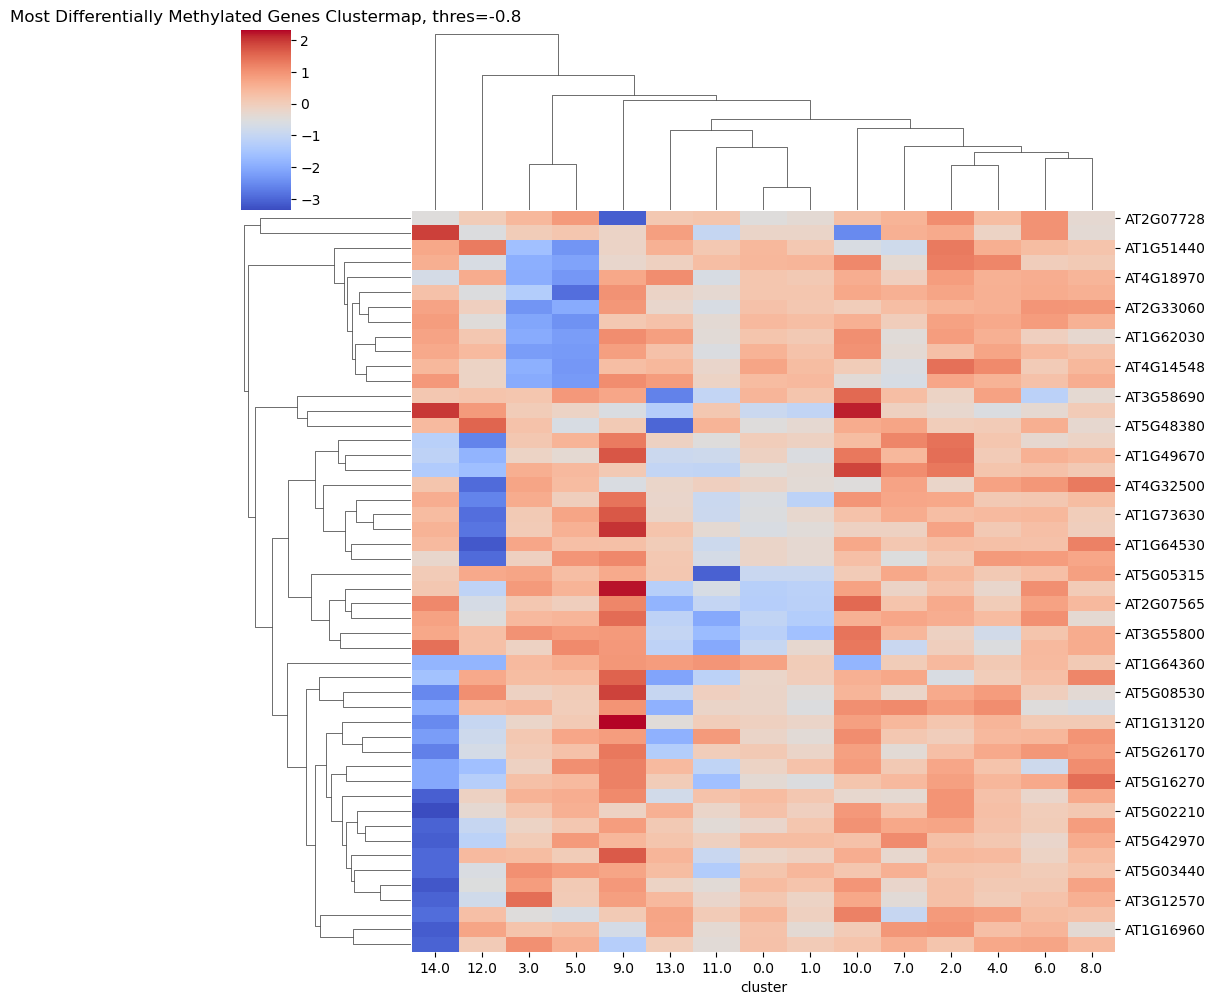

In [105]:
cluster = sns.clustermap(df_zscore, method='average', metric='euclidean', cmap='coolwarm', figsize=(10, 10))

plt.title(f'Most Differentially Methylated Genes Clustermap, thres={thres}')
# plt.savefig('/ceph/MethDev/pbio/kay/result/highMCClusterMap.pdf')
plt.show()

In [106]:
gene_order = cluster.dendrogram_row.reordered_ind
seurat_order = cluster.dendrogram_col.reordered_ind
thres_rna_df = rna_matrix.loc[below_threshold.index]#.drop(columns=[2.0,9.0], axis = 0)
thres_rna_df_reordered = thres_rna_df.iloc[gene_order,seurat_order]

In [107]:
# meth_aligned_rna_df = filtered_rna_df.iloc[gene_order,seurat_order]
# meth_aligned_rna_df
# thres_rna_df_reordered = thres_rna_df_reordered.drop(columns=[2.0,9.0], axis = 0)
thres_rna_df_reordered

cluster,14.0,12.0,3.0,5.0,9.0,13.0,11.0,0.0,1.0,10.0,7.0,2.0,4.0,6.0,8.0
AT2G07728,0.0000,0.000000,0.019108,0.005102,0.957447,0.00,0.000000,0.086116,0.082902,0.000000,0.139241,0.014535,0.015198,0.062147,0.000000
AT4G13430,0.3125,14.078431,8.073248,2.540816,0.659574,0.12,16.679487,4.210896,6.266839,63.636364,2.056962,3.244186,3.273556,8.864407,14.962406
AT1G51440,9.6250,8.784314,88.165605,279.464286,0.000000,0.00,16.897436,3.166960,4.476684,24.597403,51.816456,2.043605,3.662614,3.689266,1.872180
AT1G07720,0.0625,0.019608,80.894904,131.877551,0.489362,0.56,2.474359,2.998243,6.054404,2.129870,23.253165,0.043605,1.191489,8.785311,0.015038
AT4G18970,0.6250,0.039216,12.366242,41.622449,0.000000,0.00,14.461538,0.521968,0.642487,0.441558,0.006329,0.171512,0.197568,0.559322,0.969925
AT1G66100,15.3125,5.862745,11.891720,65.826531,3.170213,6.64,10.217949,10.049209,13.005181,8.415584,8.677215,6.482558,7.258359,5.672316,9.308271
AT2G33060,0.0625,0.000000,38.149682,33.882653,0.000000,0.00,3.102564,0.149385,1.948187,5.194805,1.221519,0.575581,0.297872,1.598870,0.090226
AT3G23450,0.5000,0.274510,12.105096,29.622449,0.074468,1.88,8.115385,0.887522,2.243523,0.831169,9.677215,0.587209,0.762918,1.559322,0.112782
AT1G62030,0.0000,1.588235,33.178344,37.612245,0.000000,0.00,3.615385,0.126538,0.137306,1.441558,3.018987,0.029070,0.015198,1.649718,0.060150
AT2G28630,0.0000,0.117647,6.168790,18.295918,0.000000,0.20,1.641026,0.156415,0.150259,0.000000,0.088608,0.061047,0.085106,0.112994,0.203008


In [108]:
rna_zscore = thres_rna_df_reordered.apply(lambda x: (x - x.mean()) / x.std(), axis=1)
# rna_zscore

<AxesSubplot:xlabel='cluster'>

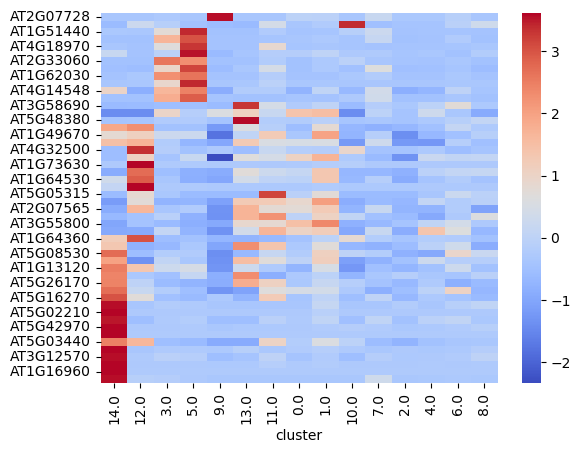

In [109]:
sns.heatmap(rna_zscore,cmap = 'coolwarm')